In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# Loading spotify tables (spark--->Pandas)
df_spotify_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()
df_spotify_user_demo = spark.table('workspace.spotify.spotify_user_demo').toPandas()

print('\nBehavior shape: ', df_spotify_user_behavior.shape, '\nDemo shape: ', df_spotify_user_demo.shape)


Behavior shape:  (108000, 26) 
Demo shape:  (108000, 6)


In [0]:
df_spotify_user_behavior.head()

,user_id,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct,playlists_followed,artists_followed,genre_diversity_score,mean_danceability,mean_energy,mean_valence,mean_acousticness,mean_speechiness,mean_instrumentalness,mean_tempo,std_energy,std_valence,std_tempo,repeat_track_rate,repeat_artist_rate,median_gap_minutes_between_plays,mean_track_popularity,pct_top_popularity_tracks
0,1,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.265243,0.36692289422245106000,0.259908069477194640,3,10,0.5929858217012658000,0.623074205391710000,0.625386269516773200,0.275635431124853840,0.492350424898302600,0.1571074347994866300,0.2137128055101844800,130.46301106864632,0.18373348299353830000,0.13646648112372328000,18.144555959319390000,0.419427,0.637569315308747900,6.6492942697982070,85.5404620165223000,0.4019210140870274000
1,2,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.118959,0.18486652918685878000,0.474921265102942000,1,3,0.4464639887799338000,0.399974886790827770,0.520803519679281600,0.449304543336722540,0.405579694155928870,0.1729281437400049000,0.4137695609500778300,130.63514198454345,0.03319677759084810000,0.10228446086365428000,14.270567147676257000,0.340590,0.360812681041394600,11.7871922313753000,82.4660722480977300,0.4398680102242990000
2,3,28.8699017515535380,1,26.6913056253024500,28.8699017515535380,0.244953,0.37373733562904693000,0.579176556554077500,2,7,0.7403383700422299000,0.539403433591158300,0.680788549744065100,0.479360274404254050,0.324238722104692500,0.2414500281071355000,0.1063399286571340400,125.46738553949213,0.15926225823101780000,0.16229209527076670000,13.336411834928860000,0.472437,0.238627132764958370,7.4129124233918370,70.9490804478548000,0.6352644085887841000
3,4,35.6438224704689800,3,23.0407140984317420,11.8812741568229950,0.508916,0.42716084080857790000,0.416055703228579770,4,313,0.3565600227317606000,0.385492221343341600,0.598479709347496000,0.390980493443033430,0.385217647370564800,0.3668335414849717700,0.1001976129452664500,106.51158580645544,0.11936122580236186000,0.06423025157850610000,16.573668958270087000,0.675425,0.421220028124161800,12.0434184794501890,59.8624277446880200,0.8708508036943563000
4,5,14.5473124274416070,1,11.0992860211953170,14.5473124274416070,0.105540,0.25317912948661997000,0.603254728153022100,1,4,0.1048483686903644200,0.260543194646781600,0.435313145346305440,0.484460735318428400,0.659995102726577500,0.3622082194280085700,0.4679643605971812000,134.90907815535150,0.20366454513359467000,0.12064031221477542000,11.401041588203093000,0.334291,0.337058551061326150,9.0933035039134800,70.1969154154419900,0.2969560993817625000


In [0]:
# 1) Manual Feature Selection (Core behavioral axes)
CLUSTER_FEATURES_V1 = [
    'daily_listening_minutes',
    'sessions_per_day',
    'days_active_last_30',
    'avg_session_minutes',
    'skip_rate',
    'liked_songs_pct',
    'ads_skipped_pct'
    ]

In [0]:
# Validate required columns exist (explicit check)

missing_cols = [col for col in (['user_id'] + CLUSTER_FEATURES_V1) if not col in df_spotify_user_behavior.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in spotify_user_behavior: {missing_cols}')

In [0]:
# Building model base
# checking null values

base =  df_spotify_user_behavior[['user_id']+CLUSTER_FEATURES_V1].copy()

print(f'{'='*25} {'Checking Null Values'} {'='* 25}')
print(base[CLUSTER_FEATURES_V1].isnull().sum())

before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V1)
after_rows = len(base)

if before_rows != after_rows:
    print(f'Dropped {before_rows - after_rows} due to nulls in selected features')

========================= Checking Null Values =========================
daily_listening_minutes    0
sessions_per_day           0
days_active_last_30        0
avg_session_minutes        0
skip_rate                  0
liked_songs_pct            0
ads_skipped_pct            0
dtype: int64


In [0]:
# Checking duplicate records
print(f'{'='* 25}{' Checking duplicate rocords in the data '}{'='*25}')
print(f'Total Duplicated Records: {base.duplicated().sum()}')

# Checking datatypes
print(f'\n{'='* 25}{' Checking datatypes '}{'='*25}')
print(base.info())


========================= Checking duplicate rocords in the data =========================
Total Duplicated Records: 0

========================= Checking datatypes =========================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  108000 non-null  int64  
 1   daily_listening_minutes  108000 non-null  object 
 2   sessions_per_day         108000 non-null  int64  
 3   days_active_last_30      108000 non-null  object 
 4   avg_session_minutes      108000 non-null  object 
 5   skip_rate                108000 non-null  float64
 6   liked_songs_pct          108000 non-null  object 
 7   ads_skipped_pct          108000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 6.6+ MB
None


In [0]:
# X_raw is the raw feature matrix in ORIGINAL units

X_raw = base[CLUSTER_FEATURES_V1].copy()
X_raw.head(2)

,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
0,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.265243,0.36692289422245106000,0.259908069477194640
1,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.118959,0.18486652918685878000,0.474921265102942000


In [0]:
# User control (grid the model)
k = 4
random_state = 42

# Algorithms used
# KMeans
# GMM

algorithms_to_run = [
    'KMeans',
    'GMM-tied',
    'GMM-full',
    'GMM-diagonal',
    'GMM-spherical'
]

methods_to_run = [
    'unscaled',
    'standard',
    'minmax',
    'robust',
    'power_yeojohnson',
    'power_boxcox',  # will be skipped if any selected feature <= 0
    'quantile_n3',
    'quantile_n5'
]

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [0]:
def transform_X(method_name: str, X: pd.DataFrame):
    """
    Returns:
    X_transformed_df (DataFrame): features matrix in the space used for fitting the model notes about skips / constraints
    """

    note = ''

    # unscaled: return a clean copy
    if method_name == 'unscaled':
        return X.copy(), note
    
    # StandardScaler: Zero - Mean, unit - std per column
    if method_name == 'standard':
        scaler = StandardScaler()
        arr = scaler.fit_transform(X)
        return pd.DataFrame(arr, columns = X.columns, index = X.index), note
    
    # MinMaxScaler: scales each column into [0, 1]
    if method_name == 'minmax':
        scaler = MinMaxScaler()
        arr = scaler.fit_transform(X)
        return pd.DataFrame(arr, columns = X.columns, index = X.index), note
    
    # RobustScaler: uses median and IQR; robust to outliers
    if method_name == 'robust':
        scaler = RobustScaler()
        arr= scaler.fit_transform(X)
        return pd.DataFrame(arr, columns = X.columns, index = X.index), note
    
    # PowerTransformer (Yeo-Johnson): handles zeros/negatives, reduces skew, standardizes
    if method_name == "power_yeojohnson":
        pt = PowerTransformer(method="yeo-johnson", standardize=True)
        arr = pt.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note
    
    # PowerTransformer (Box-Cox): requires all values strictly > 0
    if method_name == "power_boxcox":
        if (X <= 0).any().any():
            note = "SKIPPED: Box-Cox requires all values > 0"
            return None, note
        
        pt = PowerTransformer(method="box-cox", standardize=True)
        arr = pt.fit_transform(X)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note
    
    # Quantile binning into N bins (ordinal) + StandardScaler
    # (This approximates "quintile/tercile style" discretization.)
    if method_name == 'quantile_n3':
        binner = KBinsDiscretizer(n_bins = 3,
                                 encode = 'ordinal',
                                 strategy = 'quantile')
        binner = binner.fit_transform(X)
        binner_df = pd.DataFrame(binner, columns = X.columns, index = X.index)
        scaler = StandardScaler()
        arr = scaler.fit_transform(binner_df)
        return pd.DataFrame(arr, columns = X.columns, index = X.index), note
    
    if method_name == "quantile_n5":
        binner = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
        binned = binner.fit_transform(X)
        binned_df = pd.DataFrame(binned, columns=X.columns, index=X.index)

        scaler = StandardScaler()
        arr = scaler.fit_transform(binned_df)
        return pd.DataFrame(arr, columns=X.columns, index=X.index), note

    raise ValueError(f"Unknown method_name: {method_name}")



In [0]:
def fit_predict_labels(algorithm_key: str,  X_fit: pd.DataFrame, k: int, random_state: int):
    """
    Returns:
      labels (np.array): hard cluster assignments
      algo_label (str): friendly algorithm label for reporting
      extra (dict): extra metrics (inertia for KMeans; loglik/aic/bic for GMM)
    """
    extra= {}

    # KMeans
    if algorithm_key == 'KMeans':
        km = KMeans(
             n_clusters=k,
            random_state=random_state,
            n_init=20,
            max_iter=300
        )
        labels = km.fit_predict(X_fit)
        extra['inertia'] = float(km.inertia_)
        return labels, "K-Means", extra
      
    # GMM - Full covariance
    if algorithm_key == 'GMM-full':
      gmm = GaussianMixture(
        n_components = k,
        covariance_type = 'full',
        random_state = random_state,
        n_init = 5,
        max_iter = 200
      )
      labels = gmm.fit_predict(X_fit)
      extra['log_likelihood'] = float(gmm.score(X_fit) * len(X_fit))
      extra['aic'] = float(gmm.aic(X_fit))
      extra['bic'] = float(gmm.bic(X_fit))
      return labels, 'GMM-full', extra
    
     # GMM - Tied covariance
    if algorithm_key == 'GMM-tied':
      gmm = GaussianMixture(
        n_components = k,
        covariance_type = 'tied',
        random_state = random_state,
        n_init = 5,
        max_iter = 200
      )
      labels = gmm.fit_predict(X_fit)
      extra['log_likelihood'] = float(gmm.score(X_fit) * len(X_fit))
      extra['aic'] = float(gmm.aic(X_fit))
      extra['bic'] = float(gmm.bic(X_fit))
      return labels, 'GMM-tied', extra
    
     # GMM - Diagonal covariance
    if algorithm_key == 'GMM-diagonal':
      gmm = GaussianMixture(
        n_components = k,
        covariance_type = 'diag',
        random_state = random_state,
        n_init = 5,
        max_iter = 200
      )
      labels = gmm.fit_predict(X_fit)
      extra['log_likelihood'] = float(gmm.score(X_fit) * len(X_fit))
      extra['aic'] = float(gmm.aic(X_fit))
      extra['bic'] = float(gmm.bic(X_fit))
      return labels, 'GMM-diagonal', extra
    
     # GMM - Spherical covariance
    if algorithm_key == 'GMM-spherical':
      gmm = GaussianMixture(
        n_components = k,
        covariance_type = 'spherical',
        random_state = random_state,
        n_init = 5,
        max_iter = 200
      )
      labels = gmm.fit_predict(X_fit)
      extra['log_likelihood'] = float(gmm.score(X_fit) * len(X_fit))
      extra['aic'] = float(gmm.aic(X_fit))
      extra['bic'] = float(gmm.bic(X_fit))
      return labels, 'GMM-spherical', extra
    
    raise ValueError(f"Unknown algorithm_key: {algorithm_key}")


In [0]:
# Run Experiment Grid (Algorithm x Method) and build results_df

results = []

for algo_key in algorithms_to_run:
    for method_key in methods_to_run:

        # Step A: Transform raw features into fit space
        X_fit, note = transform_X(method_key, X_raw)

        # If transform is invalid (e.g., Box-Cox constraints), store "skipped" row
        if X_fit is None:
            results.append({
                "Algorithm": "(SKIPPED)",
                "Method": method_key,
                "Silhouette": np.nan,
                "Cluster_0_Count": np.nan,
                "Cluster_1_Count": np.nan,
                "Cluster_2_Count": np.nan,
                "Cluster_3_Count": np.nan,
                'Cluster_4_count:': np.nan,
                "Inertia": np.nan,
                "LogLikelihood": np.nan,
                "AIC": np.nan,
                "BIC": np.nan,
                "Note": note,
                "AlgoKey": algo_key  # keep internal key for traceability
            })
            continue

        # Step B: Fit algorithm and get hard labels
        labels, algo_label, extra = fit_predict_labels(algo_key, X_fit, k, random_state)

        # Step C: Silhouette computed in fit space (correct)
        sil = np.nan
        if len(np.unique(labels)) > 1 and len(X_fit) > k:
            sil = float(silhouette_score(X_fit, labels))

        # Step D: Cluster counts
        counts = pd.Series(labels).value_counts().sort_index()
        c0 = int(counts.get(0, 0))
        c1 = int(counts.get(1, 0))
        c2 = int(counts.get(2, 0))
        c3 = int(counts.get(3, 0))
        c4 = int(counts.get(4, 0))

        # Step E: Build results row
        row = {
            "Algorithm": algo_label,
            "Method": method_key,
            "Silhouette": sil,
            "Cluster_0_Count": c0,
            "Cluster_1_Count": c1,
            "Cluster_2_Count": c2,
            "Cluster_3_Count": c3,
            'Cluster_4_count:': c4,
            "Inertia": extra.get("inertia", np.nan),
            "LogLikelihood": extra.get("log_likelihood", np.nan),
            "AIC": extra.get("aic", np.nan),
            "BIC": extra.get("bic", np.nan),
            "Note": note,
            "AlgoKey": algo_key  # internal key so we can re-run later reliably
        }
        results.append(row)

results_df = pd.DataFrame(results)

# Add iteration numbers like your tracking sheet
results_df.insert(0, "Iteration", range(1, len(results_df) + 1))

# Round columns for readability
results_df["Silhouette"] = results_df["Silhouette"].round(3)
results_df["Inertia"] = results_df["Inertia"].round(2)
results_df["LogLikelihood"] = results_df["LogLikelihood"].round(2)
results_df["AIC"] = results_df["AIC"].round(2)
results_df["BIC"] = results_df["BIC"].round(2)

print("\n====== EXPERIMENT SUMMARY (results_df) ======")
display(results_df)

/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/databricks/python/lib/python3.12/site-packages/skle


====== EXPERIMENT SUMMARY (results_df) ======


Iteration,Algorithm,Method,Silhouette,Cluster_0_Count,Cluster_1_Count,Cluster_2_Count,Cluster_3_Count,Cluster_4_count:,Inertia,LogLikelihood,AIC,BIC,Note,AlgoKey
1,K-Means,unscaled,0.515,64364,11069,1903,30664,0,5.370342773E7,null,null,null,,KMeans
2,K-Means,standard,0.152,41989,42596,17315,6100,0,488693.28,null,null,null,,KMeans
3,K-Means,minmax,0.18,29103,21670,29439,27788,0,10090.21,null,null,null,,KMeans
4,K-Means,robust,0.16,49918,5012,36620,16450,0,296999.51,null,null,null,,KMeans
5,K-Means,power_yeojohnson,0.166,17925,37460,26899,25716,0,471012.28,null,null,null,,KMeans
6,K-Means,power_boxcox,0.165,26855,25730,37441,17974,0,472074.68,null,null,null,,KMeans
7,K-Means,quantile_n3,0.164,25004,24525,24902,33569,0,393396.19,null,null,null,,KMeans
8,K-Means,quantile_n5,0.164,30116,29173,26070,22641,0,390772.71,null,null,null,,KMeans
9,GMM-tied,unscaled,0.637,7558,93452,896,6094,0,null,-1208814.5,2417747.01,2418312.81,,GMM-tied
10,GMM-tied,standard,0.158,6710,19685,78345,3260,0,null,-890822.4,1781762.8,1782328.61,,GMM-tied


In [0]:
BEST_ITERATION_NUMBER = 3  # It can we change according to best performance

best_row = results_df.loc[results_df['Iteration'] == BEST_ITERATION_NUMBER]
if best_row.empty:
    raise ValueError(f'Iteration {BEST_ITERATION_NUMBER} not found in the results_df')

best_algo_key = best_row['AlgoKey'].iloc[0]
best_algo_labels = best_row['Algorithm'].iloc[0]
best_method_key = best_row['Method'].iloc[0]
best_note = best_row['Note'].iloc[0]

print("\n" + "=" * 70)
print("BEST ITERATION SELECTED (Option A)")
print('='* 70)
print("Iteration :", BEST_ITERATION_NUMBER)
print("Algorithm :", best_algo_labels, f"(internal key = {best_algo_key})")
print("Method    :", best_method_key)
print("Note      :", best_note)

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-6103174969405287>, line 3
      1 BEST_ITERATION_NUMBER = 3  # It can we change according to best performance
----> 3 best_row = results_df.loc[results_df['Iteration'] == BEST_ITERATION_NUMBER]
      4 if best_row.empty:
      5     raise ValueError(f'Iteration {BEST_ITERATION_NUMBER} not found in the results_df')

NameError: name 'results_df' is not defined

In [0]:
# Recreate the fit-space features for the selection best method
X_best, note_best = transform_X(best_method_key, X_raw)
if X_best is None:
    raise ValueError(f'Best Iteration uses a skipped method {best_method_key} best_method_key')

# fit - predict best label
labels_best, algo_label_check, extra_best = fit_predict_labels(best_algo_key, X_best, k, random_state)


In [0]:
# Recompute silhouette for selected best choice
sil_best = np.nan
if len(np.unique(labels_best)) > 1 and len(X_best) > k:
    sil_best = float(silhouette_score(X_best, labels_best))

print('\nRecompute best silhouette:', None if np.isnan(sil_best) else round(sil_best, 3))


Recompute best silhouette: 0.18


In [0]:
# Append labels back to the modeling input table
output_with_best_clusters = base.copy()
output_with_best_clusters['best_cluster'] = labels_best

In [0]:
# Add metadata columns
output_with_best_clusters['best_iteration'] = BEST_ITERATION_NUMBER
output_with_best_clusters['best_algorithm'] = best_algo_labels
output_with_best_clusters['best_method'] = best_method_key

print("\n===== OUTPUT WITH BEST CLUSTERS APPENDED (preview) =====")
display(output_with_best_clusters.head(20))


===== OUTPUT WITH BEST CLUSTERS APPENDED (preview) =====


user_id,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct,best_cluster,best_iteration,best_algorithm,best_method
1,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.2652434107382756,0.36692289422245106000,0.259908069477194640,0,3,K-Means,minmax
2,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.11895906967561629,0.18486652918685878000,0.474921265102942000,0,3,K-Means,minmax
3,28.8699017515535380,1,26.6913056253024500,28.8699017515535380,0.24495348616154713,0.37373733562904693000,0.579176556554077500,0,3,K-Means,minmax
4,35.6438224704689800,3,23.0407140984317420,11.8812741568229950,0.5089164221034259,0.42716084080857790000,0.416055703228579770,1,3,K-Means,minmax
5,14.5473124274416070,1,11.0992860211953170,14.5473124274416070,0.10554031013923311,0.25317912948661997000,0.603254728153022100,3,3,K-Means,minmax
6,49.0482613603114300,1,22.8677899039699530,49.0482613603114300,0.5228284880895235,0.41789807559922626000,0.501709079331418800,1,3,K-Means,minmax
7,39.0675542043531860,1,24.1310988367131200,39.0675542043531860,0.19844738038538784,0.36640395438542317000,0.797580554810954900,2,3,K-Means,minmax
8,68.7550313000483600,1,22.5645636143413060,68.7550313000483600,0.30312822049960575,0.19988937038559823000,0.351844191152380500,0,3,K-Means,minmax
9,26.5281640283802670,1,14.8994779230759220,26.5281640283802670,0.15995640202723563,0.45202474548709604000,0.238483527697036730,3,3,K-Means,minmax
10,87.1022142259386700,3,16.4727818616599430,29.0340714086462230,0.2155832200876116,0.47697352960945594000,0.667138621671540900,2,3,K-Means,minmax


# Clustering profilling + Visualization

In [0]:
## Input Assumptions

# output_with_best_clusters: columns -----> usrer_id, best_cluster
# spotify_user_demo: columns ------> user_id, age, country, city_iter, device_type, subscriptionz-tenure_months


In [0]:
# Joining clusters with demographics

df_persona = output_with_best_clusters.merge(
    df_spotify_user_demo,
    on = 'user_id',
    how = 'left'
)

print('Final joined shape: ', df_persona.shape)
df_persona.head()

Final joined shape:  (108000, 17)


,user_id,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct,best_cluster,best_iteration,best_algorithm,best_method,age,country,city_tier,device_type,subscription_tenure_months
0,1,27.8600331451566240,1,23.6207488045328230,27.8600331451566240,0.265243,0.36692289422245106000,0.259908069477194640,0,3,K-Means,minmax,49.881607316152895,UK,2,Desktop,11.3526983494597180
1,2,53.2801594511560000,1,26.0207578957064800,53.2801594511560000,0.118959,0.18486652918685878000,0.474921265102942000,0,3,K-Means,minmax,38.059871002344835,US,3,Mobile,21.7985155333668850
2,3,28.8699017515535380,1,26.6913056253024500,28.8699017515535380,0.244953,0.37373733562904693000,0.579176556554077500,0,3,K-Means,minmax,32.682443546344990,IN,1,Mobile,13.4000720878786750
3,4,35.6438224704689800,3,23.0407140984317420,11.8812741568229950,0.508916,0.42716084080857790000,0.416055703228579770,1,3,K-Means,minmax,24.275915118611570,DE,1,Desktop,24.3964678247501500
4,5,14.5473124274416070,1,11.0992860211953170,14.5473124274416070,0.105540,0.25317912948661997000,0.603254728153022100,3,3,K-Means,minmax,44.354491038023205,IN,2,Mobile,6.9213671864594880


In [0]:
# Cluster size & share distribution

cluster_sizes = df_persona['best_cluster'].value_counts().sort_index()
cluster_share = (cluster_sizes / cluster_sizes.sum()).round(3)

cluster_dist = pd.DataFrame({
    'cluster_size' : cluster_sizes,
    'cluster_share' : cluster_share
})

print('\nCluster Size & Share: ')
display(cluster_dist)


Cluster Size & Share: 


cluster_size,cluster_share
29103,0.269
21670,0.201
29439,0.273
27788,0.257


In [0]:
# Numeric Profiling

numeric_cols = ['age', 'subscription_tenure_months']

df_persona[numeric_cols] = df_persona[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

numeric_profile = (
    df_persona.groupby('best_cluster')[numeric_cols].mean().round(2)
)

display('\nNumeric Means by Cluster: ')
display(numeric_profile)

# Index vs Overall Population
overall_means = df_persona[numeric_cols].mean()
numeric_index = (numeric_profile / overall_means).round(3)

print('\nNumeric Index vs Overall (Cluster_mean / overall_mean): ')
display(numeric_index)

'\nNumeric Means by Cluster: '

age,subscription_tenure_months
32.43,18.12
32.39,17.92
32.35,18.0
32.39,18.09



Numeric Index vs Overall (Cluster_mean / overall_mean): 


age,subscription_tenure_months
1.001,1.004
1.0,0.993
0.999,0.998
1.0,1.003


In [0]:
# Categorical Profiling - Proportional Distributions

# Country Distribution
country_dist = pd.crosstab(
    df_persona['best_cluster'],
    df_persona['country']
).round(3)

print('\nCountry Distribution by Cluster: ')
display(country_dist)

# City_tier Distribution
city_tier_dist = pd.crosstab(
    df_persona['best_cluster'],
    df_persona['city_tier']
).round(3)

print('\nCity Tier Distribution by Cluster: ')
display(city_tier_dist)

# Device Type Distribution
device_dist = pd.crosstab(
    df_persona['best_cluster'],
    df_persona['device_type'],
).round(3)

print('\nDevice Type Distribution by Cluster: ')
display(device_dist)


Country Distribution by Cluster: 


BR,DE,IN,UK,US
2988,4345,7203,4281,10286
2108,3317,5451,3291,7503
2967,4298,7362,4517,10295
2700,4178,7069,4095,9746



City Tier Distribution by Cluster: 


1,2,3
11592,10260,7251
8753,7485,5432
11713,10373,7353
11216,9713,6859



Device Type Distribution by Cluster: 


Desktop,Mobile,Tablet
7419,20238,1446
5473,15107,1090
7340,20583,1516
6939,19487,1362


## Visualization


---------- Cluster Size Distribution ----------


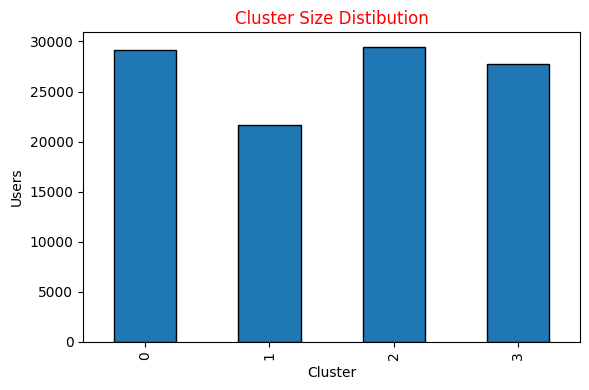


 ---------- Age Size Distribution ----------


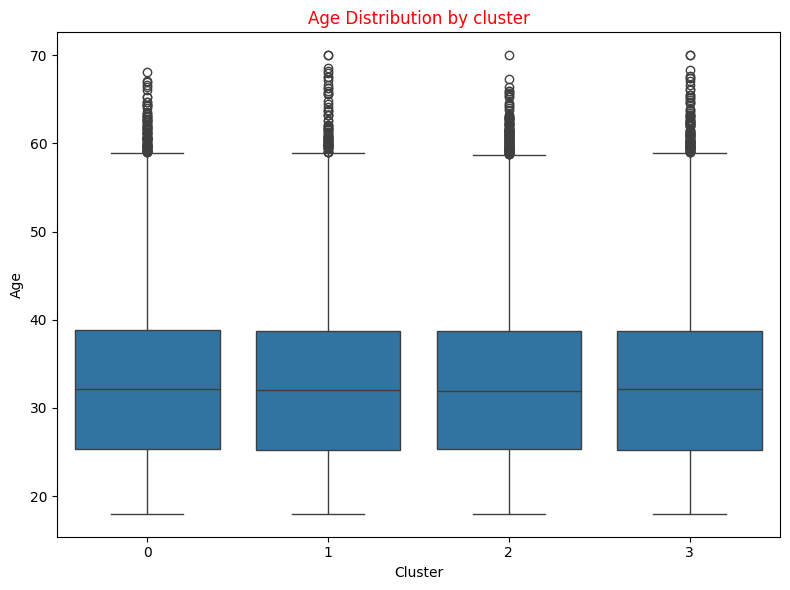


 ---------- Tenure Distribtion by Cluster ----------


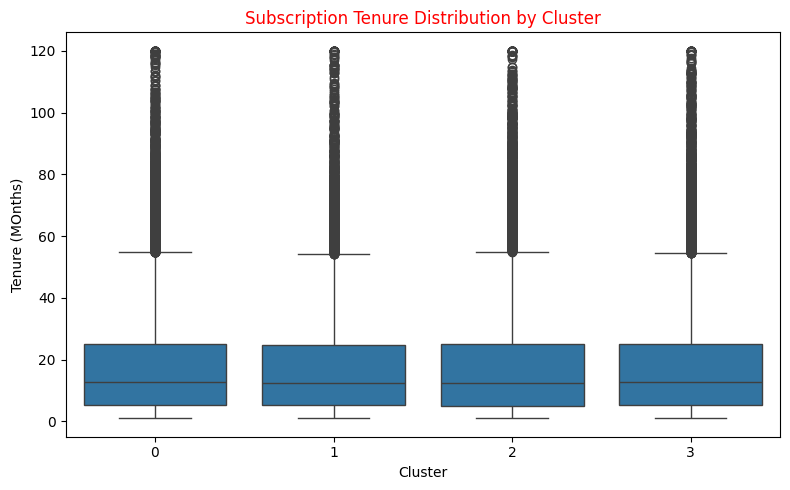


 ---------- Device Distribution ----------


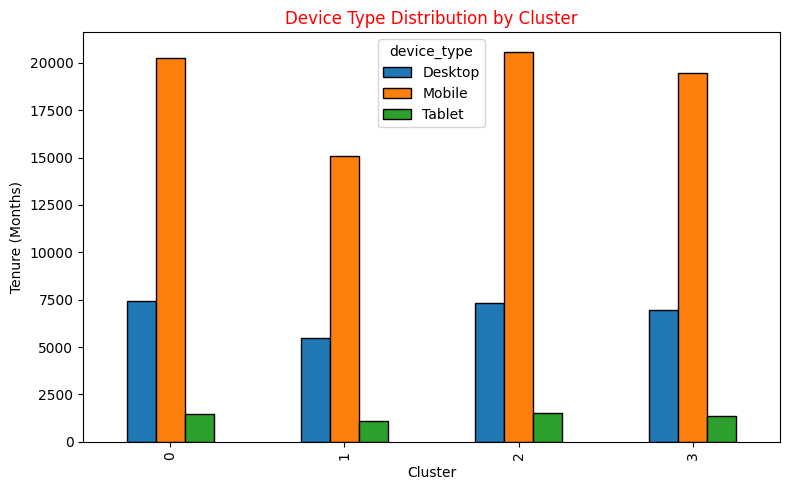


 ---------- Country Distribution (Top 6 Countries only for readability) ----------


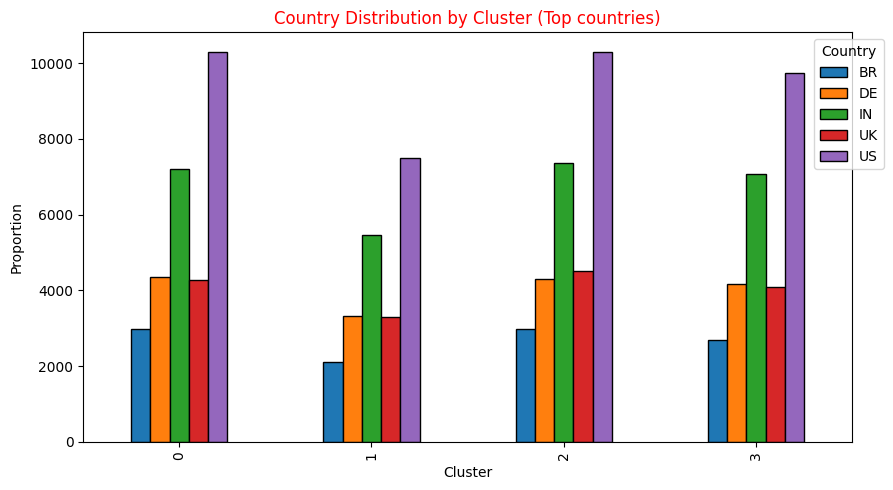

In [0]:
print(f'{'-' * 10} {"Cluster Size Distribution"} {'-' * 10}')

plt.figure(figsize = (6, 4))
df_persona['best_cluster'].value_counts().sort_index().plot(kind = 'bar', edgecolor = 'black')
plt.title('Cluster Size Distibution', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

print(f'\n {'-' * 10} {'Age Size Distribution'} {'-' * 10}')

plt.figure(figsize = (8,6))
sns.boxplot(data= df_persona,
            x = 'best_cluster',
            y = 'age')
plt.title('Age Distribution by cluster', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

print(f'\n {'-' * 10} {'Tenure Distribtion by Cluster'} {'-' * 10}')

plt.figure(figsize = (8, 5))
sns.boxplot(data = df_persona,
            x = 'best_cluster',
            y = 'subscription_tenure_months')
plt.title('Subscription Tenure Distribution by Cluster', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Tenure (MOnths)')
plt.tight_layout()
plt.show()

print(f'\n {'-' * 10} {'Device Distribution'} {'-' * 10}')
device_dist.plot(
    kind = 'bar',
    stacked = False,
    figsize = (8, 5),
    edgecolor = 'black'
)
plt.title('Device Type Distribution by Cluster', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()


print(f'\n {'-' * 10} {'Country Distribution (Top 6 Countries only for readability)'} {'-' * 10}')

top_countries = df_persona['country'].value_counts().head(6).index

country_dist_top = pd.crosstab(
    df_persona['best_cluster'],
    df_persona['country'].where(df_persona['country'].isin(top_countries), 'Other').round(3)
)

country_dist_top.plot(
    kind= 'bar',
    stacked = False,
    figsize = (9, 5),
    edgecolor = 'black'
)

plt.title('Country Distribution by Cluster (Top countries)', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title = 'Country', bbox_to_anchor = (1.05, 1),
loc = 'upper right'),
plt.tight_layout()
plt.show()


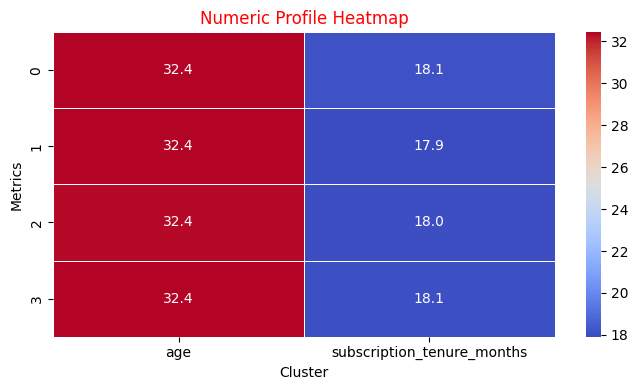

In [0]:
# Heapmap - Numeric Persona Profile

plt.figure(figsize=(7,4))
sns.heatmap(
    numeric_profile,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Numeric Profile Heatmap", color = 'red')
plt.xlabel("Cluster")
plt.ylabel("Metrics")
plt.tight_layout()
plt.show()